In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
feature_folder = pathlib.Path("../../data/processed/biolog/features/")
rast_feature_file = feature_folder / "rast/rast_ch_features.tsv"
rast_feature_file.is_file()

True

In [3]:
phenotype_folder = pathlib.Path("../../data/processed/biolog/phenotypes/")
ch_phenotype_file = phenotype_folder / "ch_phenotypes.tsv"
ch_phenotype_file.is_file()

True

In [4]:
rast_features = pd.read_csv(rast_feature_file, sep="\t", index_col=0, dtype={"genomeID": str}).astype("uint8")
rast_features[rast_features > 0] = 1
rast_features

,SSO:000020980,SSO:000009137,SSO:000009247,SSO:000001565,SSO:000021809,SSO:000003942,SSO:000001181,SSO:000021589,SSO:000019329,SSO:000021906,...,SSO:000012356,SSO:000018244,SSO:000018771,SSO:000010818,SSO:000022096,SSO:000024346,SSO:000017482,SSO:000014980,SSO:000014981,SSO:000010230
genomeID,,,,,,,,,,,,,,,,,,,,,
149698.22,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
702115.9,1,1,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1663.218,1,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
242605.18,1,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
134536.40,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134536.48,1,1,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
693973.6,0,1,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
754262.3,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
ch_phenotypes = pd.read_csv(ch_phenotype_file, sep="\t", index_col=0, dtype={"genomeID": str}).fillna(0).astype("uint8")
ch_phenotypes

,Carbon-D-Trehalose--ch_biolog,Carbon-N-Acetyl-b-D-Mannosamine--ch_biolog,Carbon-Salicin--ch_biolog,Carbon-Pectin--ch_biolog,Carbon-Dextrin--ch_biolog,Carbon-a-Hydroxy-Butyric-Acid--ch_biolog,Carbon-L-Fucose--ch_biolog,Carbon-a-D-Lactose--ch_biolog,Carbon-Citric-Acid--ch_biolog,Carbon-Acetic-Acid--ch_biolog,...,Carbon-L-Lactic-Acid--ch_biolog,Carbon-a-Keto-Glutaric-Acid--ch_biolog,Carbon-D-Fructose--ch_biolog,Carbon-L-Aspartic-Acid--ch_biolog,Carbon-N-Acetyl-Neuraminic-Acid--ch_biolog,Carbon-D-Glucose--ch_biolog,Carbon-D-Galactonic-Acid-g-Lactone--ch_biolog,Carbon-D-Mannose--ch_biolog,Carbon-Glycerol--ch_biolog,Carbon-Glycyl-L-Proline--ch_biolog
genomeID,,,,,,,,,,,,,,,,,,,,,
149698.22,1,1,1,1,1,1,0,1,1,1,...,1,1,1,0,1,1,0,1,1,1
702115.9,0,0,0,1,0,1,0,0,1,1,...,1,1,1,1,0,1,0,1,1,1
1663.218,1,0,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,0,1,1,1
242605.18,1,0,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,0,1,1,1
134536.40,0,0,0,1,0,1,0,1,1,1,...,1,1,1,1,0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134536.48,1,0,1,1,0,0,0,1,1,1,...,1,1,1,1,1,1,0,1,1,1
693973.6,0,0,0,0,1,0,0,0,0,1,...,1,1,0,0,0,0,0,0,0,0
754262.3,1,0,0,0,1,1,0,1,0,0,...,0,1,1,1,0,1,0,1,0,0


In [6]:
from trait_prediction.feature_selection.reduction import remove_features_with_low_variance, remove_features_with_high_correlation

In [7]:
rast_features_highvar, low_var_features = remove_features_with_low_variance(rast_features, threshold=0.01)
# nunique = rast_features.nunique()
# low_var_features = nunique[nunique == 1].index
# rast_features_highvar = rast_features.drop(low_var_features, axis=1)

In [8]:
features, correlated_features_dict = remove_features_with_high_correlation(
    rast_features_highvar, threshold=0.95, method="numpy"
)

In [9]:
len(low_var_features), len(correlated_features_dict)

(3181, 3378)

In [10]:
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_validate

In [11]:
categorical_feature_names = list(features.columns)
clf = CatBoostClassifier(
    # iterations=1000,
    # depth=8,
    # learning_rate=0.03,
    # l2_leaf_reg=3,
    # bootstrap_type="Bayesian",
    # bagging_temperature=1,
    # random_state=np.random.randint(0, 1000),
    objective="Logloss",
    cat_features=categorical_feature_names,
    verbose=False,
    allow_writing_files=False,
)

In [12]:
common_genomes = features.index.intersection(ch_phenotypes.index)
len(common_genomes)

362

In [13]:
X = features.loc[common_genomes, :]
y = ch_phenotypes.loc[common_genomes, "Carbon-Acetic-Acid--ch_biolog"]
scoring = (
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "matthews_corrcoef",
)
n_splits = 5
n_jobs = -1

In [14]:
cv_results = cross_validate(
    clf,
    X.loc[common_genomes, :],  # type: ignore
    y,
    scoring=scoring,
    cv=n_splits,  # this is StratifiedKFold if y is binary or multiclass
    n_jobs=n_jobs,
    return_estimator=True,
    return_indices=True,  # type: ignore
)

In [15]:
cv_estimators, cv_indices = cv_results["estimator"], cv_results["indices"]

In [16]:
scores = {
k.lstrip("test_"): v for k, v in cv_results.items() if k.startswith("test_")
}
scores_df = pd.DataFrame(scores)
scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef
0,0.753425,0.526316,0.750000,1.000000,0.857143,0.657895,0.198680
1,0.698630,0.472222,0.728571,0.944444,0.822581,0.788499,-0.122798
2,0.805556,0.777778,0.900000,0.833333,0.865385,0.899177,0.522233
3,0.902778,0.866435,0.925926,0.943396,0.934579,0.968222,0.745948
4,0.847222,0.744290,0.850000,0.962264,0.902655,0.969215,0.577809


In [17]:
"""
accuracy	balanced_accuracy	precision	recall	f1	roc_auc	matthews_corrcoef
0	0.753425	0.526316	0.750000	1.000000	0.857143	0.651072	0.198680
1	0.698630	0.472222	0.728571	0.944444	0.822581	0.796296	-0.122798
2	0.805556	0.777778	0.900000	0.833333	0.865385	0.894033	0.522233
3	0.888889	0.857001	0.924528	0.924528	0.924528	0.972195	0.714002
4	0.847222	0.744290	0.850000	0.962264	0.902655	0.973188	0.577809
"""

'\naccuracy\tbalanced_accuracy\tprecision\trecall\tf1\troc_auc\tmatthews_corrcoef\n0\t0.753425\t0.526316\t0.750000\t1.000000\t0.857143\t0.651072\t0.198680\n1\t0.698630\t0.472222\t0.728571\t0.944444\t0.822581\t0.796296\t-0.122798\n2\t0.805556\t0.777778\t0.900000\t0.833333\t0.865385\t0.894033\t0.522233\n3\t0.888889\t0.857001\t0.924528\t0.924528\t0.924528\t0.972195\t0.714002\n4\t0.847222\t0.744290\t0.850000\t0.962264\t0.902655\t0.973188\t0.577809\n'

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'accuracy'),
  Text(1, 0, 'balanced_accuracy'),
  Text(2, 0, 'precision'),
  Text(3, 0, 'recall'),
  Text(4, 0, 'f1'),
  Text(5, 0, 'roc_auc'),
  Text(6, 0, 'matthews_corrcoef')])

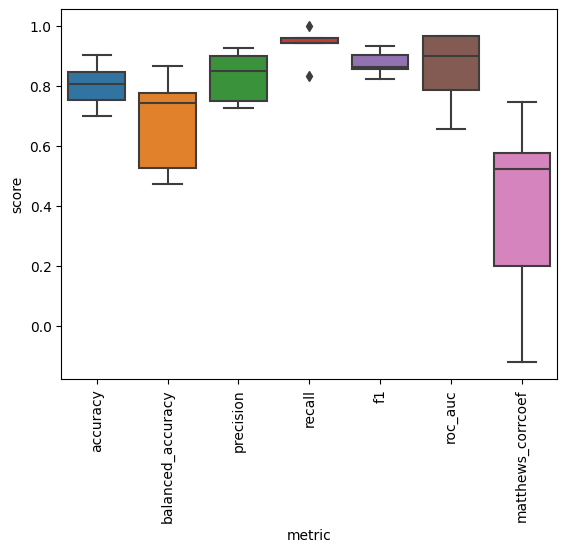

In [19]:
scores_df_melt = scores_df.melt(var_name="metric", value_name="score")
sns.boxplot(data=scores_df_melt, x="metric", y="score")
plt.xticks(rotation=90)

In [20]:
import shap

def plot_shap_summary(
    clf,
    feature_data: pd.DataFrame,
    title: str,
    output_file: str,
) -> pd.Series:
    """
    Plot SHAP summary plot.

    Parameters
    ----------
    clf
        Classifier object
    feature_data : pd.DataFrame
        Feature data.
    title : str
        The title of the plot (phenotype name)
    output_file : str
        Output file path.
    """
    feature_labels = list(feature_data.columns)
    explainer = shap.Explainer(clf)
    shap_values = explainer(feature_data)
    shap_values.feature_names = feature_labels
    # Summarize the SHAP values to get the mean absolute value for each feature
    shap_sum = np.abs(shap_values.values).mean(axis=0)
    # Create a pandas Series for easy plotting and manipulation, with feature names
    importance_df = pd.Series(shap_sum, index=feature_labels).sort_values(
        ascending=False
    )
    return importance_df

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [21]:
importances = []
for i, estimator in enumerate(cv_estimators):
    genomes = X.index[cv_indices["train"][i]]
    importance_series = plot_shap_summary(
        estimator,
        X,
        title="Carbon-Acetic-Acid",
        output_file=f"../../results/figures/shap_summary_{i}.png",
    )
    importances.append(set(importance_series.head(20).index))

importances_df = pd.DataFrame(importances)
importances_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,SSO:000000524,SSO:000040206,SSO:000025945,SSO:000005954,SSO:000010144,SSO:000012456,SSO:000025929,SSO:000012313,SSO:000025834,SSO:000033761,SSO:000025924,SSO:000005188,SSO:000012787,SSO:000004899,SSO:000002133,SSO:000023758,SSO:000005036,SSO:000020441,SSO:000006885,SSO:000006616
1,SSO:000034208,SSO:000001398,SSO:000023666,SSO:000031760,SSO:000010261,SSO:000011075,SSO:000012313,SSO:000033761,SSO:000014836,SSO:000007115,SSO:000028986,SSO:000022400,SSO:000008469,SSO:000007205,SSO:000016545,SSO:000005036,SSO:000020441,SSO:000023042,SSO:000001768,SSO:000020822
2,SSO:000040206,SSO:000025945,SSO:000004806,SSO:000001398,SSO:000024655,SSO:000005954,SSO:000000330,SSO:000012313,SSO:000022710,SSO:000021874,SSO:000000230,SSO:000025834,SSO:000001935,SSO:000033761,SSO:000020343,SSO:000012787,SSO:000028986,SSO:000038373,SSO:000005036,SSO:000006885
3,SSO:000040206,SSO:000025945,SSO:000008470,SSO:000017457,SSO:000010147,SSO:000011075,SSO:000021553,SSO:000000330,SSO:000016257,SSO:000012313,SSO:000022710,SSO:000007101,SSO:000025834,SSO:000014836,SSO:000005188,SSO:000006885,SSO:000012466,SSO:000005036,SSO:000025375,SSO:000024130
4,SSO:000040206,SSO:000002349,SSO:000004806,SSO:000001398,SSO:000010609,SSO:000012456,SSO:000011075,SSO:000016257,SSO:000028617,SSO:000000330,SSO:000025834,SSO:000002851,SSO:000017621,SSO:000012787,SSO:000028986,SSO:000006885,SSO:000008576,SSO:000023312,SSO:000002887,SSO:000024130


In [22]:
set.intersection(*importances)

set()

In [23]:
"{'SSO:000040206'}"

"{'SSO:000040206'}"